# Task 4: Bucketing FICO Scores (Quantization)

**Context**
- Charlie's model architecture needs **categorical** input, but FICO scores are a fine-grained
  integer (300-850). She needs them mapped into a small number of buckets - a **rating**, where
  lower rating = better credit.
- She wants a *general* method: given a target number of buckets, find the boundaries that best
  summarize the data - not a one-off manual cut.

**Task**
- Build a rating map: FICO score -> bucket/rating.
- Two ways to define "best": minimize **mean squared error** (MSE) of representing each score by
  its bucket's mean, or maximize **log-likelihood** of the observed default pattern under a
  piecewise-constant default-rate model.
- Task suggests solving via **dynamic programming**.

**Approach**
- Both objectives get solved *optimally* (not greedily/heuristically) via the same dynamic
  programming structure - just a different per-segment cost function plugged in.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

##Learnings

## Concept 1: what is quantization?
Quantization just means **replacing many possible values with a small set of representative
buckets** - like rounding every price to the nearest dollar, or sorting ages into "18-25",
"26-35", etc. You lose some precision (two people with FICO 610 and 645 might land in the same
bucket even though they're not identical), but you gain something a downstream model can actually
use as a category. The real question is always: **where do you draw the boundaries** so you lose
as little useful information as possible?

## 1. Load & prepare data
Aggregate to **one row per unique FICO score** first (n = number of borrowers at that score,
k = number who defaulted). FICO is an integer, and buckets are always contiguous ranges of scores
- so this loses zero information versus working row-by-row, while cutting the problem from
10,000 rows down to ~370 unique score values (makes the dynamic program far cheaper to run).

In [2]:
df = pd.read_csv('Task_3_and_4_Loan_Data.csv')

agg = (df.groupby('fico_score')
         .agg(n=('default', 'size'), k=('default', 'sum'))
         .reset_index()
         .sort_values('fico_score')
         .reset_index(drop=True))

scores = agg['fico_score'].values
n_arr = agg['n'].values.astype(float)   # borrowers at this score
k_arr = agg['k'].values.astype(float)   # defaults at this score
m = len(agg)
print(f'{m} unique FICO scores, spanning {scores.min()}-{scores.max()}, {int(n_arr.sum())} borrowers total')

374 unique FICO scores, spanning 408-850, 10000 borrowers total


## 2. MSE-optimal bucketing
**Objective:** if every borrower in a bucket gets represented by that bucket's *mean* FICO score,
minimize the total squared error across all borrowers. This is exactly **1-D k-means clustering** -
a purely score-based split that doesn't look at default outcomes at all.

**Cost of one candidate bucket** (a contiguous range of scores): `sum((x - bucket_mean)^2)` over
every borrower in it. Using running totals (prefix sums of count, sum, and sum-of-squares) lets us
compute any bucket's cost in O(1) instead of re-summing every time - a standard trick whenever
you need the cost of *many* possible sub-ranges of the same array.

In [7]:
cum_n   = np.concatenate([[0], np.cumsum(n_arr)])
cum_nx  = np.concatenate([[0], np.cumsum(n_arr * scores)])
cum_nx2 = np.concatenate([[0], np.cumsum(n_arr * scores**2)])
cum_k   = np.concatenate([[0], np.cumsum(k_arr)])

def mse_cost(i, j):
    """Squared-error cost of bucketing unique-score-index range [i, j) together."""
    N = cum_n[j] - cum_n[i]
    if N == 0:
        return 0.0
    S, S2 = cum_nx[j] - cum_nx[i], cum_nx2[j] - cum_nx2[i]
    mean = S / N
    return S2 - 2 * mean * S + N * mean**2   # = sum(n*(x-mean)^2), expanded to avoid a second pass

In [8]:
def optimal_buckets(cost_fn, m, n_buckets):
    """Generic optimal partition-into-k-contiguous-buckets solver.
    dp[k, j] = lowest total cost of splitting the first j score-indices into k buckets.
    split[k, j] = the cut point that achieved that best cost (for backtracking the boundaries)."""
    INF = float('inf')
    dp = np.full((n_buckets + 1, m + 1), INF)
    dp[0, 0] = 0
    split = np.full((n_buckets + 1, m + 1), -1, dtype=int)

    for k in range(1, n_buckets + 1):
        for j in range(1, m + 1):
            for i in range(k - 1, j):          # try every possible start of the last bucket
                if dp[k - 1, i] == INF:
                    continue
                candidate = dp[k - 1, i] + cost_fn(i, j)
                if candidate < dp[k, j]:
                    dp[k, j] = candidate
                    split[k, j] = i

    # backtrack from the full solution to recover the actual boundary indices
    boundaries, j = [], m
    for k in range(n_buckets, 0, -1):
        i = split[k, j]
        boundaries.append(i)
        j = i
    boundaries.reverse()
    return dp[n_buckets, m], boundaries

def report_buckets(boundaries, m, label):
    edges = boundaries + [m]
    print(f'{label}:')
    for a, b in zip(edges[:-1], edges[1:]):
        N, K = cum_n[b] - cum_n[a], cum_k[b] - cum_k[a]
        print(f'  FICO [{scores[a]:>3}, {scores[b-1]:>3}]  n={int(N):>5}  defaults={int(K):>4}  PD={K/N:.3f}')

In [9]:
N_BUCKETS = 5
mse_total_cost, mse_boundaries = optimal_buckets(mse_cost, m, N_BUCKETS)
report_buckets(mse_boundaries, m, 'MSE-optimal buckets')

MSE-optimal buckets:
  FICO [408, 552]  n=  797  defaults= 428  PD=0.537
  FICO [553, 607]  n= 2240  defaults= 635  PD=0.283
  FICO [608, 654]  n= 3036  defaults= 488  PD=0.161
  FICO [655, 706]  n= 2634  defaults= 242  PD=0.092
  FICO [707, 850]  n= 1293  defaults=  58  PD=0.045


## 3. Log-likelihood-optimal bucketing
**Why MSE isn't quite the right objective for this business problem:** it only cares about
compressing FICO scores accurately - it has no idea some scores default far more than others. We
actually want buckets that are *homogeneous in default risk*, since that's what feeds a PD model.

**The log-likelihood objective, explained simply:** assume every borrower within a bucket
defaults independently with the *same* probability `p`. Given `n` borrowers and `k` observed
defaults in a bucket, the natural (maximum-likelihood) estimate is `p = k/n`. The log-likelihood
term `k*log(p) + (n-k)*log(1-p)` measures how well that constant-`p` story fits what we actually
observed - it's largest (least negative) when the bucket's borrowers really do share a similar
default rate, and gets penalized when a bucket lumps together very different risk levels (because
no single `p` explains both groups well). **Maximizing total log-likelihood over the choice of
boundaries = finding cut points that make each bucket's default rate as internally consistent as
possible** - which is exactly the categorical feature Charlie's model needs.

Same dynamic programming shape as before - just a different cost function. We minimize *negative*
log-likelihood so it plugs into the same "minimize total cost" DP unchanged.

In [10]:
def ll_cost(i, j):
    """Negative log-likelihood cost of bucketing range [i, j) together (to be minimized)."""
    N, K = cum_n[j] - cum_n[i], cum_k[j] - cum_k[i]
    if N == 0:
        return 0.0
    p = K / N
    if p <= 0 or p >= 1:      # a bucket with zero or all defaults has no uncertainty -> zero cost
        return 0.0
    return -(K * np.log(p) + (N - K) * np.log(1 - p))

ll_total_cost, ll_boundaries = optimal_buckets(ll_cost, m, N_BUCKETS)
report_buckets(ll_boundaries, m, 'Log-likelihood-optimal buckets')

Log-likelihood-optimal buckets:
  FICO [408, 520]  n=  301  defaults= 199  PD=0.661
  FICO [521, 580]  n= 1407  defaults= 536  PD=0.381
  FICO [581, 640]  n= 3438  defaults= 703  PD=0.204
  FICO [641, 696]  n= 3197  defaults= 336  PD=0.105
  FICO [697, 850]  n= 1657  defaults=  77  PD=0.046


## 4. Compare the two
Plot both sets of boundaries against the raw default-rate curve by FICO score.

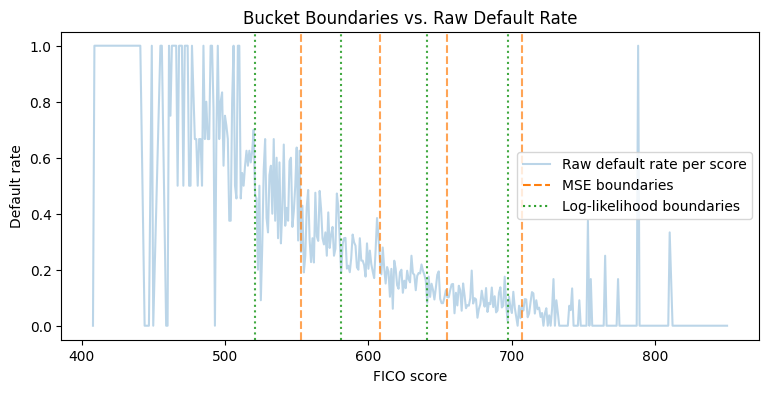

In [11]:
default_rate_by_score = k_arr / n_arr
plt.plot(scores, default_rate_by_score, alpha=0.3, label='Raw default rate per score')

for b in mse_boundaries[1:]:
    plt.axvline(scores[b], color='C1', linestyle='--', alpha=0.7)
for b in ll_boundaries[1:]:
    plt.axvline(scores[b], color='C2', linestyle=':', alpha=0.9)

plt.plot([], [], color='C1', linestyle='--', label='MSE boundaries')
plt.plot([], [], color='C2', linestyle=':', label='Log-likelihood boundaries')
plt.xlabel('FICO score'); plt.ylabel('Default rate')
plt.title('Bucket Boundaries vs. Raw Default Rate')
plt.legend(); plt.show()

**Read:** the log-likelihood boundaries sit noticeably lower (further left) than the MSE ones
in the low-FICO region - it's spending an extra bucket separating the *riskiest* borrowers, where
default rate is changing fastest, instead of splitting the score range evenly. MSE doesn't know
default even exists as a concept; it just spaces buckets to represent the score distribution well.
For a rating meant to predict PD, **log-likelihood is the right objective to keep.**

## 5. Final rating map
Lower rating = better credit, so rating 1 = the safest (highest-FICO) bucket. Uses the
log-likelihood boundaries.

In [12]:
ll_edges = [scores[b] for b in ll_boundaries[1:]]   # internal cut points, ascending FICO order

def fico_to_rating(fico_score):
    """Map a raw FICO score to a rating (1 = best/lowest-risk bucket)."""
    bucket_from_low = np.searchsorted(ll_edges, fico_score, side='right')  # 0 = lowest FICO bucket
    n_buckets = len(ll_edges) + 1
    return n_buckets - bucket_from_low   # flip so higher FICO -> lower (better) rating

for test_score in [410, 550, 600, 650, 700, 800]:
    print(f'FICO {test_score} -> rating {fico_to_rating(test_score)}')

FICO 410 -> rating 5
FICO 550 -> rating 4
FICO 600 -> rating 3
FICO 650 -> rating 2
FICO 700 -> rating 1
FICO 800 -> rating 1


## Summary
- Both MSE and log-likelihood bucketing are solved **optimally** via the same dynamic-programming
  shell - just swap the per-segment cost function.
- MSE gives the best summary of the *score distribution itself*; log-likelihood gives the best
  summary of *default risk* - the latter is what a PD-predicting model actually needs, so it's
  the one used in the final `fico_to_rating(...)` map.
- Every bucket's own PD (from Task 4) plugs directly into the expected-loss formula from Task 3
  (`PD x EAD x LGD`) - the two tasks connect end to end.

**Scope notes (deliberately out for a 1-2hr introductory prototype):**
- Number of buckets was fixed at 5, matching the prompt's framing ("given a set number of
  buckets") - not selected via cross-validation or an information criterion (AIC/BIC), which
  would be the natural next step if Charlie needed the bucket *count* optimized too, not just
  the boundaries.
- The DP is O(m^2 x k) over ~370 unique scores - fast here, but would need the classic
  "monotonic boundary" optimization (SMAWK / knot removal) to scale to a much finer-grained
  variable with far more unique values.